# 家計調査データ概要・傾向分析

**事前準備(このノートブックを開く前に1回だけ):**

1. ローカルの `data/` フォルダ(以下の2ファイルが入っている)を、Googleドライブのマイドライブ直下に**フォルダ名のまま**アップロード
   - `kakei_savings_debt_by_income.csv`
   - `kakei_surplus_rate_by_income_quintile.csv`
2. 下のセルを上から順に実行(最初のセルでDriveへのアクセス許可を求められるので許可)

> マイドライブの別の場所に置いた場合は、下の `CANDIDATE_DIRS` に自分のパスを追加してください。

In [1]:
!pip install -q japanize-matplotlib

zsh:1: command not found: pip


In [2]:
import japanize_matplotlib

In [3]:
import os

IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# 上から順に探して最初に見つかったフォルダを使う
CANDIDATE_DIRS = [
    "data",                                  # ノートブックと同じ階層に data/ がある場合(ローカル実行時)
    "/content/drive/MyDrive/data",            # Driveのマイドライブ直下に data フォルダを置いた場合
    "/content/data",                          # files.upload() でColabセッションに直接置いた場合
]

DATA_DIR = None
for d in CANDIDATE_DIRS:
    if os.path.isdir(d) and os.path.exists(os.path.join(d, "kakei_savings_debt_by_income.csv")):
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "data フォルダが見つかりません。CANDIDATE_DIRS に自分の実際のパスを追加するか、\n"
        "Googleドライブのマイドライブ直下に 'data' という名前でフォルダをアップロードしてください。"
    )

print("使用するデータフォルダ:", DATA_DIR)

使用するデータフォルダ: data


## 1. データ読み込み

In [4]:
import pandas as pd

df_savings = pd.read_csv(f"{DATA_DIR}/kakei_savings_debt_by_income.csv")
df_surplus = pd.read_csv(f"{DATA_DIR}/kakei_surplus_rate_by_income_quintile.csv")

print("貯蓄・負債データ:", df_savings.shape)
print("黒字率データ:", df_surplus.shape)

貯蓄・負債データ: (5184, 5)
黒字率データ: (3150, 6)


## 2. データセットの概要

**出典: 総務省統計局「家計調査」(e-Stat)**

| ファイル | 統計表ID | 対象世帯 | 期間 |
|---|---|---|---|
| kakei_savings_debt_by_income.csv | 0002210009(貯蓄・負債編) | 二人以上の世帯 | 2002〜2025年(四半期) |
| kakei_surplus_rate_by_income_quintile.csv | 0002200003(家計収支編) | 勤労者世帯 | 2000〜2026年(四半期) |

In [5]:
def describe_columns(df: pd.DataFrame, name: str):
    print(f"=== {name} ===")
    print("列:", list(df.columns))
    print("行数:", len(df))
    for col in df.columns:
        if df[col].dtype == object or df[col].nunique() < 20:
            uniques = df[col].unique()
            print(f"  [{col}] ユニーク数={df[col].nunique()} -> {list(uniques)[:20]}")
        else:
            print(f"  [{col}] dtype={df[col].dtype}, min={df[col].min()}, max={df[col].max()}")
    print()

describe_columns(df_savings, "貯蓄・負債データ")
describe_columns(df_surplus, "黒字率データ")

=== 貯蓄・負債データ ===
列: ['項目', '年間収入階級', '時期', '値', '単位']
行数: 5184
  [項目] ユニーク数=3 -> ['年間収入', '貯蓄', '負債']
  [年間収入階級] ユニーク数=18 -> ['200万円未満', '200～250万円', '250～300万円', '300～350万円', '350～400万円', '400～450万円', '450～500万円', '500～550万円', '550～600万円', '600～650万円', '650～700万円', '700～750万円', '750～800万円', '800～900万円', '900～1000万円', '1000～1250万円', '1250～1500万円', '1500万円以上']
  [時期] dtype=int64, min=2002000103, max=2025001012
  [値] dtype=int64, min=13, max=5475
  [単位] ユニーク数=1 -> ['万円']

=== 黒字率データ ===
列: ['項目', '世帯区分', '年間収入五分位', '時期', '値', '単位']
行数: 3150
  [項目] ユニーク数=6 -> ['実収入', '消費支出', '可処分所得', '黒字', '平均消費性向', '黒字率']
  [世帯区分] ユニーク数=1 -> ['勤労者世帯']
  [年間収入五分位] ユニーク数=5 -> ['年収五分位1', '年収五分位2', '年収五分位3', '年収五分位4', '年収五分位5']
  [時期] dtype=int64, min=2000000103, max=2026000103
  [値] dtype=float64, min=4.4, max=1174990.0
  [単位] ユニーク数=2 -> ['円', '％']



## 3. 年収階級別 貯蓄・負債(全期間平均)

In [6]:
INCOME_ORDER = ['200万円未満','200～250万円','250～300万円','300～350万円','350～400万円',
                '400～450万円','450～500万円','500～550万円','550～600万円','600～650万円',
                '650～700万円','700～750万円','750～800万円','800～900万円','900～1000万円',
                '1000～1250万円','1250～1500万円','1500万円以上']

pivot_savings = df_savings.pivot_table(index="年間収入階級", columns="項目", values="値", aggfunc="mean")
pivot_savings = pivot_savings.reindex(INCOME_ORDER)
pivot_savings["貯蓄/年収倍率"] = (pivot_savings["貯蓄"] / pivot_savings["年間収入"]).round(2)
pivot_savings["負債/年収倍率"] = (pivot_savings["負債"] / pivot_savings["年間収入"]).round(2)
pivot_savings.round(0)

項目,年間収入,負債,貯蓄,貯蓄/年収倍率,負債/年収倍率
年間収入階級,,,,,
200万円未満,156.0,65.0,916.0,6.0,0.0
200～250万円,225.0,119.0,1127.0,5.0,1.0
250～300万円,275.0,112.0,1359.0,5.0,0.0
300～350万円,324.0,137.0,1544.0,5.0,0.0
350～400万円,373.0,190.0,1679.0,4.0,1.0
400～450万円,423.0,294.0,1673.0,4.0,1.0
450～500万円,473.0,404.0,1610.0,3.0,1.0
500～550万円,522.0,498.0,1607.0,3.0,1.0
550～600万円,573.0,585.0,1580.0,3.0,1.0


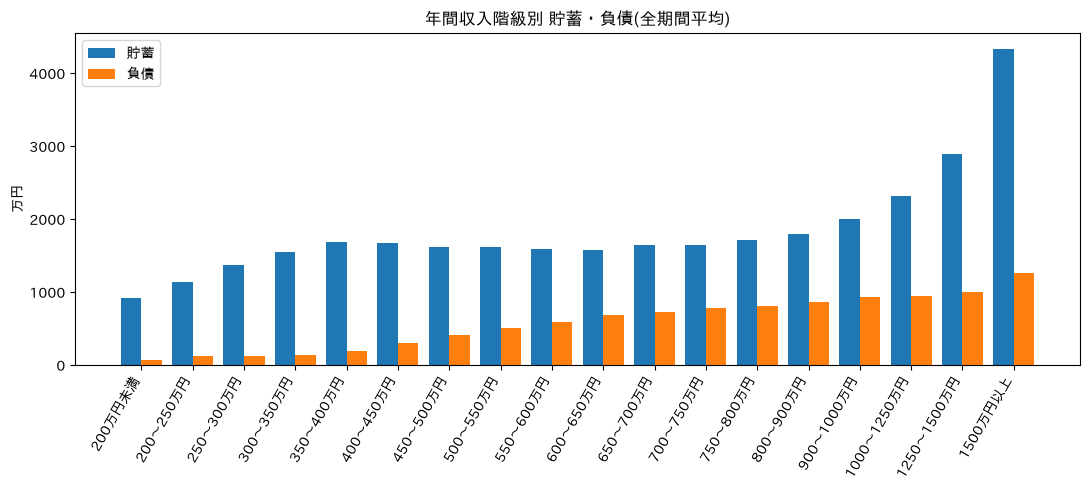

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(INCOME_ORDER))
width = 0.4
ax.bar([i - width/2 for i in x], pivot_savings["貯蓄"], width=width, label="貯蓄")
ax.bar([i + width/2 for i in x], pivot_savings["負債"], width=width, label="負債")
ax.set_xticks(list(x))
ax.set_xticklabels(INCOME_ORDER, rotation=60, ha="right")
ax.set_ylabel("万円")
ax.set_title("年間収入階級別 貯蓄・負債(全期間平均)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. 年収五分位別 黒字率の推移(2000〜2025年)

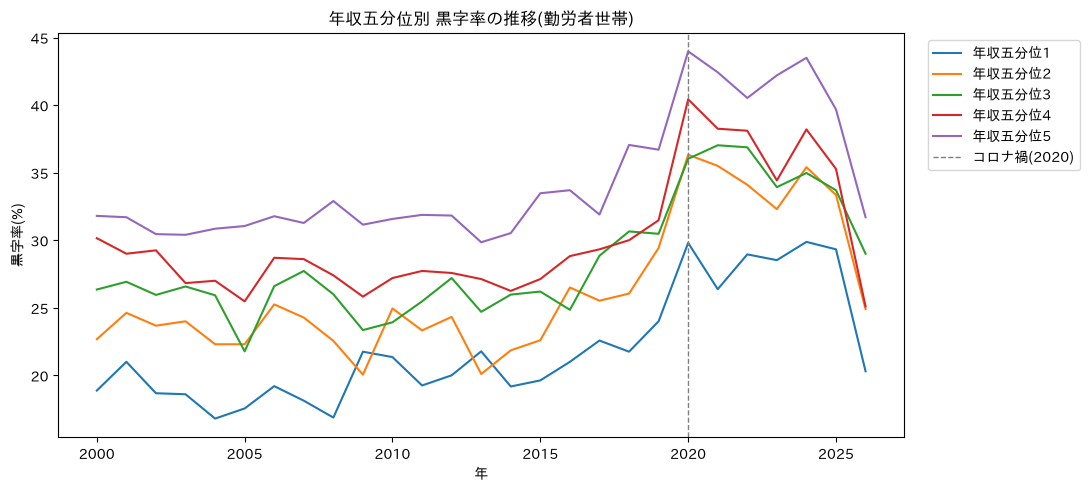

直近5年の平均黒字率:


年間収入五分位,年収五分位1,年収五分位2,年収五分位3,年収五分位4,年収五分位5
年,,,,,
2022,28.950,34.10,36.875,38.100,40.525
2023,28.525,32.30,33.925,34.425,42.200
2024,29.875,35.40,34.975,38.200,43.500
2025,29.325,33.35,33.700,35.275,39.675
2026,20.300,24.90,29.000,25.100,31.700


In [8]:
df_surplus["年"] = df_surplus["時期"].astype(str).str[:4].astype(int)
QUINTILES = ["年収五分位1", "年収五分位2", "年収五分位3", "年収五分位4", "年収五分位5"]

rate_by_year = (
    df_surplus[df_surplus["項目"] == "黒字率"]
    .groupby(["年", "年間収入五分位"])["値"].mean()
    .unstack()[QUINTILES]
)

fig, ax = plt.subplots(figsize=(11, 5))
rate_by_year.plot(ax=ax)
ax.axvline(2020, color="gray", linestyle="--", linewidth=1, label="コロナ禍(2020)")
ax.set_ylabel("黒字率(%)")
ax.set_title("年収五分位別 黒字率の推移(勤労者世帯)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("直近5年の平均黒字率:")
rate_by_year.tail(5)

## 5. 可処分所得の使い道(消費 vs 貯蓄)

項目       平均消費性向   黒字率
年間収入五分位              
年収五分位1     78.1  21.9
年収五分位2     73.7  26.3
年収五分位3     71.6  28.4
年収五分位4     69.8  30.2
年収五分位5     65.6  34.4


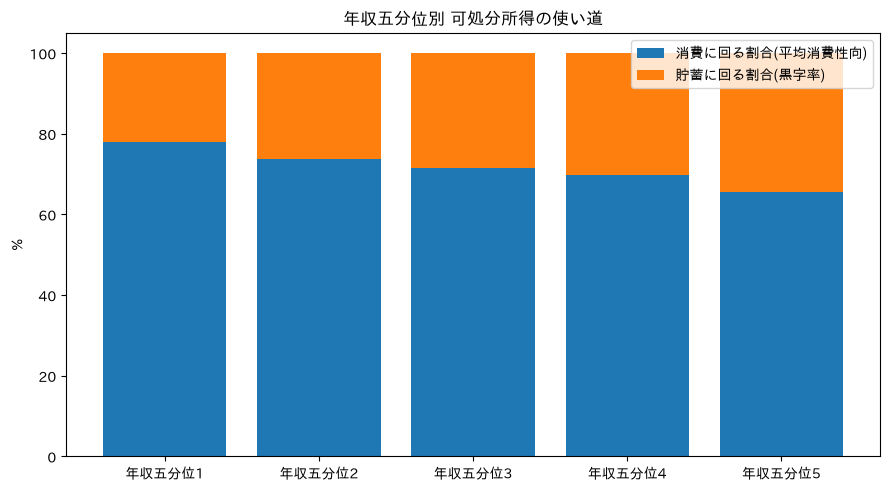

In [9]:
summary = (
    df_surplus[df_surplus["項目"].isin(["平均消費性向", "黒字率"])]
    .groupby(["年間収入五分位", "項目"])["値"].mean()
    .unstack()
    .reindex(QUINTILES)
)
print(summary.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
bottom = summary["平均消費性向"]
ax.bar(summary.index, summary["平均消費性向"], label="消費に回る割合(平均消費性向)")
ax.bar(summary.index, summary["黒字率"], bottom=bottom, label="貯蓄に回る割合(黒字率)")
ax.set_ylabel("%")
ax.set_title("年収五分位別 可処分所得の使い道")
ax.legend()
plt.tight_layout()
plt.show()

## 6. 家計タイプのクラスタリング(K-means)

「年間収入階級 × 四半期」ごとの年間収入・貯蓄・負債の値をサンプルとして扱い、K-meansで家計をいくつかのタイプに分類します。
分類したクラスタの平均的な特徴を基準にすることで、あとから自分の家計データ(年収・貯蓄・負債)を入力し、「似たタイプの家計と比べて自分はどうか」を比較できるようにします。

In [10]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df_savings["年"] = df_savings["時期"].astype(str).str[:4].astype(int)

household_wide = (
    df_savings.pivot_table(index=["年間収入階級", "年", "時期"], columns="項目", values="値")
    .reset_index()
)
household_wide["貯蓄/年収倍率"] = household_wide["貯蓄"] / household_wide["年間収入"]
household_wide["負債/年収倍率"] = household_wide["負債"] / household_wide["年間収入"]

FEATURE_COLS = ["年間収入", "貯蓄", "負債", "貯蓄/年収倍率", "負債/年収倍率"]
print("クラスタリング対象サンプル数:", len(household_wide))
household_wide[["年間収入階級", "年"] + FEATURE_COLS].head()

クラスタリング対象サンプル数: 1728


項目,年間収入階級,年,年間収入,貯蓄,負債,貯蓄/年収倍率,負債/年収倍率
0,1000～1250万円,2002,1103.0,2147.0,890.0,1.946510,0.806890
1,1000～1250万円,2002,1112.0,2101.0,857.0,1.889388,0.770683
2,1000～1250万円,2002,1107.0,2067.0,882.0,1.867209,0.796748
3,1000～1250万円,2002,1104.0,2055.0,871.0,1.861413,0.788949
4,1000～1250万円,2003,1102.0,2041.0,787.0,1.852087,0.714156


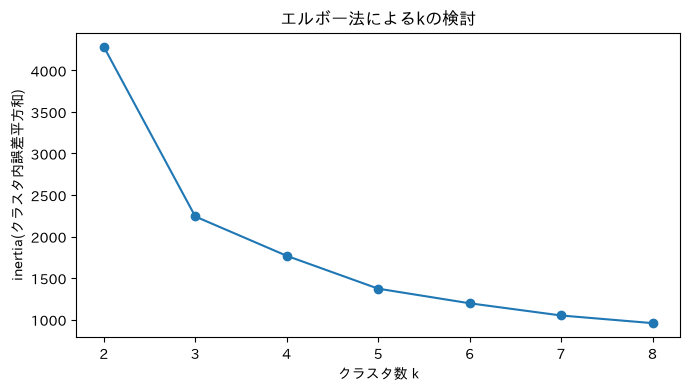

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(household_wide[FEATURE_COLS])

inertias = []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(K_RANGE), inertias, marker="o")
ax.set_xlabel("クラスタ数 k")
ax.set_ylabel("inertia(クラスタ内誤差平方和)")
ax.set_title("エルボー法によるkの検討")
plt.tight_layout()
plt.show()

In [12]:
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
household_wide["クラスタ"] = kmeans.fit_predict(X_scaled)

cluster_profile = household_wide.groupby("クラスタ")[FEATURE_COLS].mean().round(2)
cluster_profile["サンプル数"] = household_wide.groupby("クラスタ").size()
cluster_profile = cluster_profile.sort_values("年間収入")
cluster_profile

項目,年間収入,貯蓄,負債,貯蓄/年収倍率,負債/年収倍率,サンプル数
クラスタ,,,,,,
0,299.82,1392.79,154.09,4.83,0.49,582
3,650.75,1636.77,670.09,2.59,1.02,764
1,1134.45,2396.30,953.15,2.11,0.85,284
2,1967.28,4317.59,1243.83,2.20,0.63,98


クラスタ × 年間収入階級 の対応(件数):
クラスタ          0   1   2   3
年間収入階級                     
200万円未満      96   0   0   0
200～250万円    94   0   0   2
250～300万円    96   0   0   0
300～350万円    96   0   0   0
350～400万円    96   0   0   0
400～450万円    84   0   0  12
450～500万円    19   0   0  77
500～550万円     1   0   0  95
550～600万円     0   0   0  96
600～650万円     0   0   0  96
650～700万円     0   0   0  96
700～750万円     0   0   0  96
750～800万円     0   0   0  96
800～900万円     0   1   0  95
900～1000万円    0  93   0   3
1000～1250万円   0  96   0   0
1250～1500万円   0  94   2   0
1500万円以上      0   0  96   0


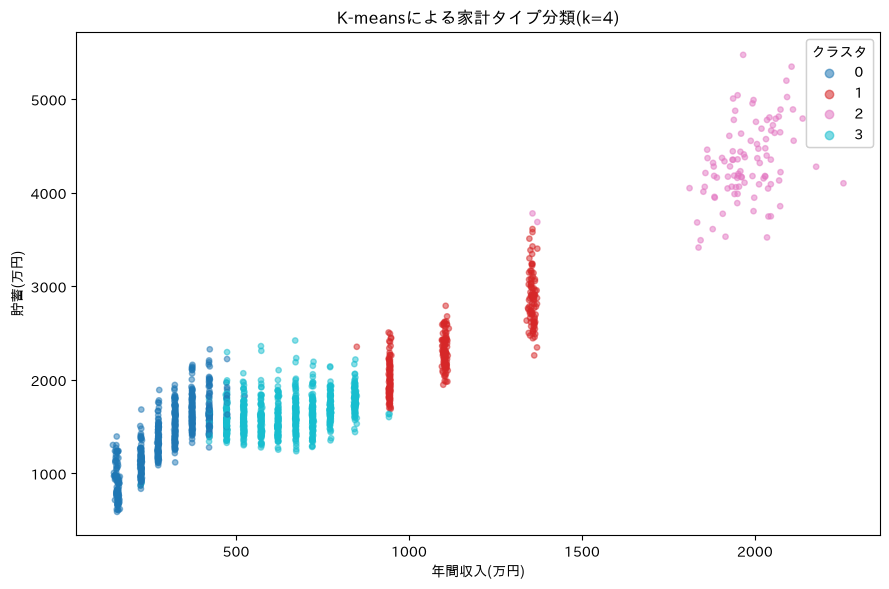

In [13]:
print("クラスタ × 年間収入階級 の対応(件数):")
print(pd.crosstab(household_wide["年間収入階級"], household_wide["クラスタ"]).reindex(INCOME_ORDER))

fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(
    household_wide["年間収入"], household_wide["貯蓄"],
    c=household_wide["クラスタ"], cmap="tab10", alpha=0.5, s=15,
)
ax.set_xlabel("年間収入(万円)")
ax.set_ylabel("貯蓄(万円)")
ax.set_title(f"K-meansによる家計タイプ分類(k={N_CLUSTERS})")
legend = ax.legend(*scatter.legend_elements(), title="クラスタ")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

## 7. 自分の家計データを入力して比較する

年収・貯蓄・負債(すべて万円単位)を入力すると、最も近い家計タイプ(クラスタ)に分類し、そのタイプの平均的な特徴と比較します。

In [14]:
def classify_household(annual_income_man, savings_man, debt_man):
    savings_ratio = savings_man / annual_income_man
    debt_ratio = debt_man / annual_income_man
    x = pd.DataFrame([[annual_income_man, savings_man, debt_man, savings_ratio, debt_ratio]], columns=FEATURE_COLS)
    cluster = kmeans.predict(scaler.transform(x))[0]
    profile = cluster_profile.loc[cluster]

    print(f"あなたの家計は クラスタ{cluster} に分類されました(同タイプのサンプル数: {int(profile['サンプル数'])})")
    print(f"  年間収入      : あなた {annual_income_man:>6.0f}万円 / クラスタ平均 {profile['年間収入']:>6.0f}万円")
    print(f"  貯蓄          : あなた {savings_man:>6.0f}万円 / クラスタ平均 {profile['貯蓄']:>6.0f}万円")
    print(f"  負債          : あなた {debt_man:>6.0f}万円 / クラスタ平均 {profile['負債']:>6.0f}万円")
    print(f"  貯蓄/年収倍率 : あなた {savings_ratio:>6.2f}   / クラスタ平均 {profile['貯蓄/年収倍率']:>6.2f}")
    print(f"  負債/年収倍率 : あなた {debt_ratio:>6.2f}   / クラスタ平均 {profile['負債/年収倍率']:>6.2f}")
    return cluster

# 使用例: 年収・貯蓄・負債を自分の数字に書き換えて実行してください(単位: 万円)
classify_household(annual_income_man=600, savings_man=1200, debt_man=500)

あなたの家計は クラスタ3 に分類されました(同タイプのサンプル数: 764)
  年間収入      : あなた    600万円 / クラスタ平均    651万円
  貯蓄          : あなた   1200万円 / クラスタ平均   1637万円
  負債          : あなた    500万円 / クラスタ平均    670万円
  貯蓄/年収倍率 : あなた   2.00   / クラスタ平均   2.59
  負債/年収倍率 : あなた   0.83   / クラスタ平均   1.02


np.int32(3)